In [32]:
# import bioframe as bf
import torch
from gpzoo.kernels import batched_RBF, batched_MGGP_RBF
from torch import distributions
import matplotlib.pyplot as plt
from torch import nn, optim
from tqdm.autonotebook import tqdm
from gpzoo.utilities import add_jitter, whitened_KL
from gpzoo.gp import WSVGP, MGGP_WSVGP
import cooler
from matplotlib.colors import LogNorm
import numpy as np
import cooltools
import pandas as pd
import os, subprocess

In [33]:
# Define the grid range and resolution
grid_size = 30  # Number of points per dimension
x1 = torch.linspace(-2, 2, grid_size)
x2 = torch.linspace(-2, 2, grid_size)

# Create a meshgrid
x1, x2 = torch.meshgrid(x1, x2, indexing="ij")

# Stack to get a grid of shape (grid_size * grid_size, 2)
X = torch.stack([x1.flatten(), x2.flatten()], dim=1)

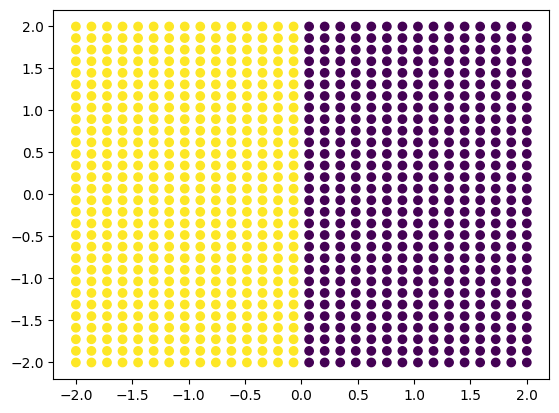

In [34]:
groups = (X[:,0] < 0).type(torch.long) 
plt.scatter(X[:, 0], X[:, 1], c=groups)

In [49]:
M = 500
jitter = 1e-5

kernel = batched_MGGP_RBF(sigma=0.4, lengthscale=1.0, group_diff_param=5.0, n_groups=2)
gp = MGGP_WSVGP(kernel, M=M, jitter=jitter, n_groups=2)

idx = torch.multinomial(torch.ones(X.shape[0]), num_samples=M, replacement=False)

gp.Lu = nn.Parameter(1e-4*torch.eye(M).clone())
gp.Z = nn.Parameter(torch.tensor(X[idx]), requires_grad=False)
gp.groupsZ = nn.Parameter(groups[idx], requires_grad=False)
# mu = torch.squeeze(torch.stack((torch.torch.sin(torch.pi * gp.Z/10.0), torch.cos(torch.pi * gp.Z/10.0), torch.torch.sin(torch.pi * gp.Z/10.0))))
mu = gp.init_mean(X, X, groupsX=groups)
gp.mu = nn.Parameter(mu.T)

torch.Size([900, 500])
torch.Size([900, 2])


/tmp/ipykernel_766528/3035395013.py:10: UserWarning: To copy construct from a tensor, it is recommended to use sourceTensor.clone().detach() or sourceTensor.clone().detach().requires_grad_(True), rather than torch.tensor(sourceTensor).
  gp.Z = nn.Parameter(torch.tensor(X[idx]), requires_grad=False)


In [50]:
gp.mu.shape

torch.Size([2, 500])

In [51]:
X.shape

torch.Size([900, 2])

In [52]:
qF, qZ, pZ = gp(X, diag=False, groupsX=groups)

In [53]:
N = 25
F_samples = qF.sample((N,)).detach()
F_mean = qF.mean.detach()

In [54]:
F_samples.shape

torch.Size([25, 2, 900])

In [55]:
qF, qZ, pZ = gp(F_samples[0].T, diag=False, groupsX=groups)

In [56]:
single_sample = qF.sample().detach()

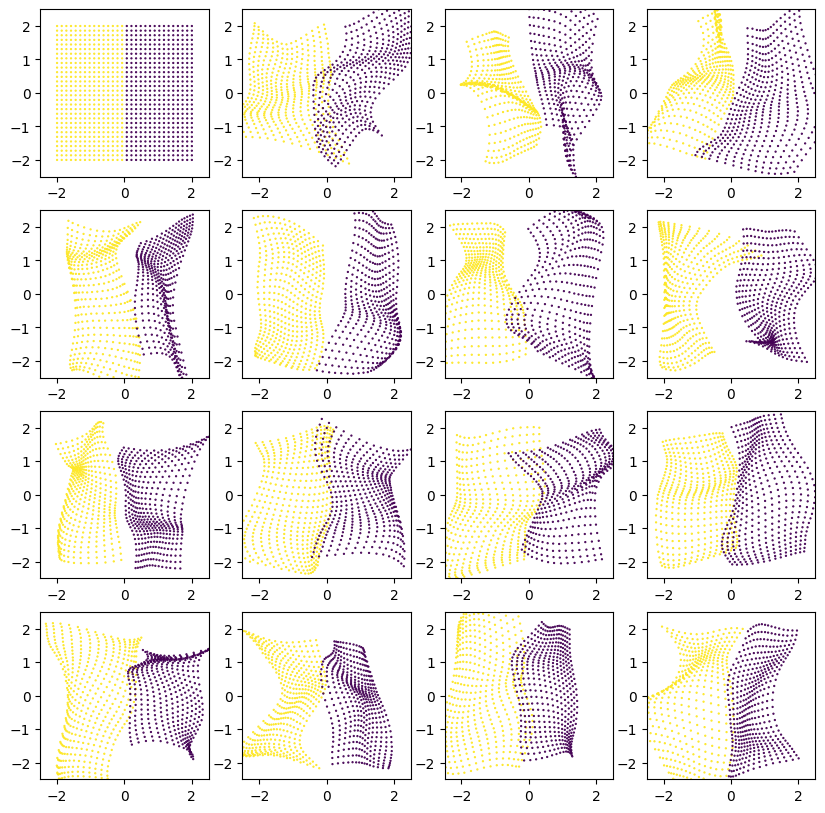

In [57]:
plt.figure(figsize=(10, 10))
for i in range(16):
    plt.subplot(4, 4, i+1)
    if i==0:
        plt.scatter(X[:, 0], X[:, 1], s=0.4, c=groups)
    else:
        plt.scatter(F_samples[i, 0], F_samples[i, 1], s=0.4, c=groups)

    plt.xlim([-2.5, 2.5])
    plt.ylim([-2.5, 2.5])



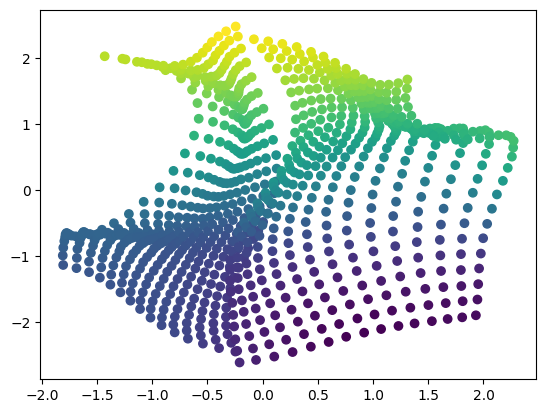

In [109]:
i = 24
plt.scatter(F_samples[0, 0], F_samples[0, 1], c=single_sample[1])

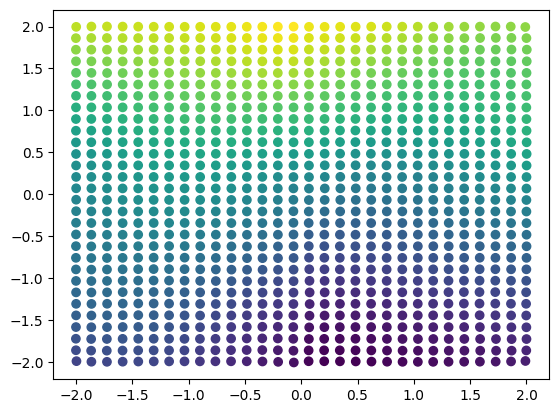

In [110]:
i = 24
plt.scatter(F_mean[0], F_mean[1], c=F_samples[i, 1])

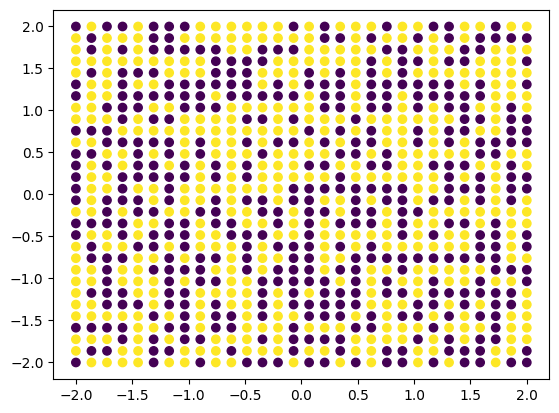

In [12]:
torch.manual_seed(0)
groups = torch.randint(low=0, high=2, size= (len(X),) ).type(torch.long)
plt.scatter(X[:, 0], X[:, 1], c=groups)

In [18]:
M = 800
jitter = 1e-3

kernel = batched_MGGP_RBF(sigma=0.4, lengthscale=1.0, group_diff_param=0.1, n_groups=2)
gp = MGGP_WSVGP(kernel, M=M, jitter=jitter, n_groups=2)

idx = torch.multinomial(torch.ones(X.shape[0]), num_samples=M, replacement=False)

gp.Lu = nn.Parameter(1e-4*torch.eye(M).clone())
gp.Z = nn.Parameter(torch.tensor(X[idx]), requires_grad=False)
gp.groupsZ = nn.Parameter(groups[idx], requires_grad=False)
# mu = torch.squeeze(torch.stack((torch.torch.sin(torch.pi * gp.Z/10.0), torch.cos(torch.pi * gp.Z/10.0), torch.torch.sin(torch.pi * gp.Z/10.0))))
mu = gp.init_mean(X, X, groupsX=groups)
gp.mu = nn.Parameter(mu.T)

torch.Size([900, 800])
torch.Size([900, 2])


/tmp/ipykernel_3078647/2746608363.py:10: UserWarning: To copy construct from a tensor, it is recommended to use sourceTensor.clone().detach() or sourceTensor.clone().detach().requires_grad_(True), rather than torch.tensor(sourceTensor).
  gp.Z = nn.Parameter(torch.tensor(X[idx]), requires_grad=False)


In [19]:
qF, qZ, pZ = gp(X, diag=False, groupsX=groups, verbose=False)

In [20]:
N = 25
F_samples = qF.sample((N,)).detach()
F_mean = qF.mean.detach()

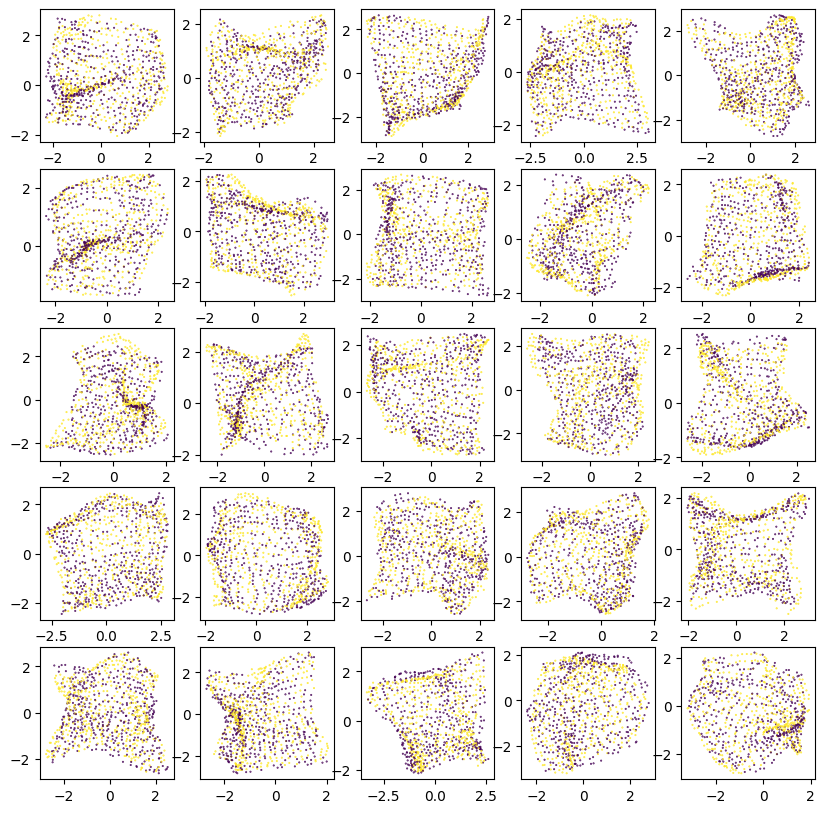

In [21]:
plt.figure(figsize=(10, 10))
for i in range(N):
    plt.subplot(5, 5, i+1)
    plt.scatter(F_samples[i, 0], F_samples[i, 1], s=0.2, c=groups)